In [25]:
!pip install ultralytics kagglehub

In [26]:
import kagglehub
from ultralytics import YOLO
import os

In [27]:
path = kagglehub.dataset_download(
    "anushkagovindkadam/smart-helmet-detection-using-dl"
)

print("Dataset downloaded at:", path)

Using Colab cache for faster access to the 'smart-helmet-detection-using-dl' dataset.
Dataset downloaded at: /kaggle/input/smart-helmet-detection-using-dl


In [28]:
for root, dirs, files in os.walk(path):
    print(root)
    break

/kaggle/input/smart-helmet-detection-using-dl


In [29]:
dataset_root = path + "/data"
print(dataset_root)

/kaggle/input/smart-helmet-detection-using-dl/data


In [30]:
print(os.listdir(dataset_root))

['data.yaml', 'vaid', 'test', 'train']


In [31]:
data_yaml = """
path: """ + dataset_root + """

train: train/images
val: train/images

names:
  0: helmet
  1: no_helmet
"""

In [32]:
model = YOLO("yolov8m.pt")

In [35]:
import os

# create working folder safely
os.makedirs("/content", exist_ok=True)

yaml_path = "/content/data.yaml"

In [36]:
with open(yaml_path, "w") as f:
    f.write(f"""
path: {dataset_root}

train: train/images
val: train/images

names:
  0: helmet
  1: no_helmet
""")

print("YAML created at:", yaml_path)

YAML created at: /content/data.yaml


In [39]:
import os

dataset_root = "/kaggle/input/smart-helmet-detection-using-dl/data"

print(os.path.exists(dataset_root))
print(os.listdir(dataset_root))

True
['data.yaml', 'vaid', 'test', 'train']


In [40]:
import os

dataset_root = "/kaggle/input/smart-helmet-detection-using-dl/data"

yaml_path = "/kaggle/working/data.yaml"

os.makedirs("/kaggle/working", exist_ok=True)

data_yaml = f"""
path: {dataset_root}

train: train/images
val: valid/images   # ⚠️ FIX THIS if valid folder exists

names:
  0: helmet
  1: no_helmet
"""

with open(yaml_path, "w") as f:
    f.write(data_yaml)

print("YAML created at:", yaml_path)

YAML created at: /kaggle/working/data.yaml


In [41]:
print(os.listdir(dataset_root))

['data.yaml', 'vaid', 'test', 'train']


In [43]:
import os

dataset_root = "/kaggle/input/smart-helmet-detection-using-dl/data"

for root, dirs, files in os.walk(dataset_root):
    print(root)

/kaggle/input/smart-helmet-detection-using-dl/data
/kaggle/input/smart-helmet-detection-using-dl/data/vaid
/kaggle/input/smart-helmet-detection-using-dl/data/vaid/labels
/kaggle/input/smart-helmet-detection-using-dl/data/vaid/images
/kaggle/input/smart-helmet-detection-using-dl/data/test
/kaggle/input/smart-helmet-detection-using-dl/data/test/labels
/kaggle/input/smart-helmet-detection-using-dl/data/test/images
/kaggle/input/smart-helmet-detection-using-dl/data/train
/kaggle/input/smart-helmet-detection-using-dl/data/train/labels
/kaggle/input/smart-helmet-detection-using-dl/data/train/images


In [44]:
import os

dataset_root = "/kaggle/input/smart-helmet-detection-using-dl/data"
yaml_path = "/kaggle/working/data.yaml"

os.makedirs("/kaggle/working", exist_ok=True)

data_yaml = f"""
path: {dataset_root}

train: train/images
val: test/images   # ✅ FIXED HERE

names:
  0: helmet
  1: no_helmet
"""

with open(yaml_path, "w") as f:
    f.write(data_yaml)

print("YAML fixed and saved!")

YAML fixed and saved!


In [46]:
import os

dataset_root = "/content/datasets"  # or your path

for root, dirs, files in os.walk(dataset_root):
    print(root, "->", len(files), "files")

In [47]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    patience=30,   # prevent early stopping too fast
    device=0
)

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=30, perspective=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b79b899a120>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [48]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-7/weights/best.pt")

In [50]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'yolov8m.pt', 'runs', 'yolo26n.pt', 'dataset', 'data.yaml', 'yolov8n.pt', 'sample_data']


In [54]:
import os
print(os.listdir("/content"))

['.config', 'drive', 'yolov8m.pt', 'runs', 'yolo26n.pt', 'dataset', 'data.yaml', 'yolov8n.pt', 'sample_data']


In [56]:
import urllib.request

url = "https://ultralytics.com/images/bus.jpg"  # sample test image
file_name = "test.jpg"

urllib.request.urlretrieve(url, file_name)

results = model.predict(
    source=file_name,
    conf=0.25,
    save=True
)


image 1/1 /content/test.jpg: 640x480 (no detections), 39.2ms
Speed: 3.1ms preprocess, 39.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


In [57]:
import os
print(os.listdir("/content/runs/detect/"))

['train-2', 'predict', 'train-4', 'train-5', 'train-3', 'train-7', 'train-6', 'helmet_detection', 'train']


In [58]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train-7/weights/best.pt")

In [59]:
import urllib.request

# sample image (people / traffic)
url = "https://ultralytics.com/images/bus.jpg"
img_path = "helmet_test.jpg"

urllib.request.urlretrieve(url, img_path)

results = model.predict(
    source=img_path,
    conf=0.25,
    save=True
)


image 1/1 /content/helmet_test.jpg: 640x480 (no detections), 9.8ms
Speed: 3.9ms preprocess, 9.8ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2


In [60]:
import os
print(os.listdir("/content/runs/detect/"))

['train-2', 'predict', 'train-4', 'train-5', 'train-3', 'train-7', 'train-6', 'helmet_detection', 'predict-2', 'train']


In [62]:
from ultralytics import YOLO
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt
import os

In [63]:
model = YOLO("/content/runs/detect/train-7/weights/best.pt")

In [64]:
url = "https://ultralytics.com/images/bus.jpg"
img_path = "test.jpg"

urllib.request.urlretrieve(url, img_path)

('test.jpg', <http.client.HTTPMessage at 0x7b7b637d6330>)

In [65]:
results = model.predict(
    source=img_path,
    conf=0.25,
    save=True
)


image 1/1 /content/test.jpg: 640x480 (no detections), 6.8ms
Speed: 3.2ms preprocess, 6.8ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-3


In [66]:
print(results[0].save_dir)

/content/runs/detect/predict-3


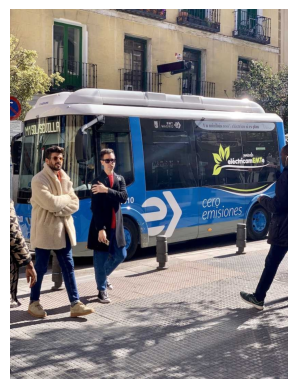

In [67]:
output_img_path = results[0].save_dir + "/test.jpg"

img = Image.open(output_img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [68]:
results = model.val()

Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 48.2±32.6 MB/s, size: 17.6 KB)
val: Scanning /kaggle/input/smart-helmet-detection-using-dl/data/train/labels... 366 images, 2 backgrounds, 273 corrupt: 100% ━━━━━━━━━━━━ 368/368 505.1it/s 0.7s
val: /kaggle/input/smart-helmet-detection-using-dl/data/train/images/BikesHelmets100_png.rf.1dc0acfeed1395f89caa01b1eedfd7cb - Copy.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 2. Possible class labels are 0-1
val: /kaggle/input/smart-helmet-detection-using-dl/data/train/images/BikesHelmets113_png.rf.9a1f4f698900bb4e56aac34184458bcd.jpg: ignoring corrupt image/label: Label class 6 exceeds dataset class count 2. Possible class labels are 0-1
val: /kaggle/input/smart-helmet-detection-using-dl/data/train/images/BikesHelmets11_png.rf.4a6dbca7d5dcff31ad6facc87b11cd1c.jpg: ignoring corrupt image/label: Label class 3 exceeds dataset class co

In [69]:
precision = results.results_dict['metrics/precision(B)']
recall = results.results_dict['metrics/recall(B)']
map50 = results.results_dict['metrics/mAP50(B)']
map5095 = results.results_dict['metrics/mAP50-95(B)']

print("===== HELMET DETECTION RESULTS =====")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"mAP@50     : {map50:.4f}")
print(f"mAP@50-95  : {map5095:.4f}")

===== HELMET DETECTION RESULTS =====
Precision  : 0.9980
Recall     : 0.9191
mAP@50     : 0.9392
mAP@50-95  : 0.7947



image 1/1 /content/test.jpg: 640x480 (no detections), 10.9ms
Speed: 4.4ms preprocess, 10.9ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-3


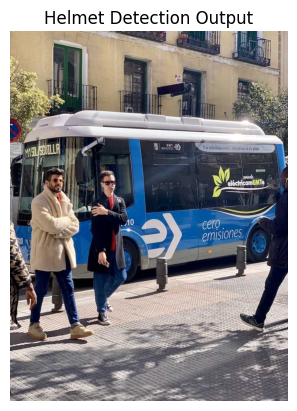

In [70]:
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

# download sample image
url = "https://ultralytics.com/images/bus.jpg"
img_path = "test.jpg"
urllib.request.urlretrieve(url, img_path)

# predict
results = model.predict(source=img_path, conf=0.25, save=True)

# show result
output_img = results[0].save_dir + "/test.jpg"

img = Image.open(output_img)
plt.imshow(img)
plt.axis("off")
plt.title("Helmet Detection Output")
plt.show()

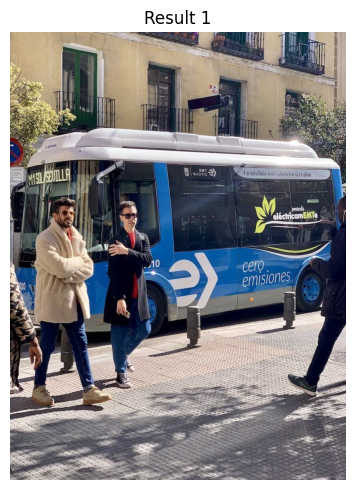

In [96]:
import matplotlib.pyplot as plt
import cv2
from glob import glob

# get prediction images (after YOLO run)
pred_images = glob("runs/detect/predict/*.jpg")

# take only 3 images
pred_images = pred_images[:3]

plt.figure(figsize=(15,5))

for i, img_path in enumerate(pred_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i+1)
    plt.imshow(img)
    plt.title(f"Result {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [97]:
from glob import glob

pred_images = glob("runs/detect/**/**/*.jpg", recursive=True)
print("Total prediction images found:", len(pred_images))
print(pred_images)

Total prediction images found: 134
['runs/detect/val-2/val_batch0_labels.jpg', 'runs/detect/val-2/val_batch0_pred.jpg', 'runs/detect/val-2/val_batch1_labels.jpg', 'runs/detect/val-2/val_batch2_labels.jpg', 'runs/detect/val-2/val_batch1_pred.jpg', 'runs/detect/val-2/val_batch2_pred.jpg', 'runs/detect/val/val_batch0_labels.jpg', 'runs/detect/val/val_batch0_pred.jpg', 'runs/detect/val/val_batch1_labels.jpg', 'runs/detect/val/val_batch2_labels.jpg', 'runs/detect/val/val_batch1_pred.jpg', 'runs/detect/val/val_batch2_pred.jpg', 'runs/detect/predict/test.jpg', 'runs/detect/predict-5/helmet_test.jpg', 'runs/detect/predict-5/img1.jpg', 'runs/detect/predict-5/test.jpg', 'runs/detect/predict-5/img2.jpg', 'runs/detect/train-4/val_batch0_labels.jpg', 'runs/detect/train-4/train_batch421.jpg', 'runs/detect/train-4/train_batch1.jpg', 'runs/detect/train-4/train_batch0.jpg', 'runs/detect/train-4/val_batch0_pred.jpg', 'runs/detect/train-4/val_batch1_labels.jpg', 'runs/detect/train-4/labels.jpg', 'runs/de

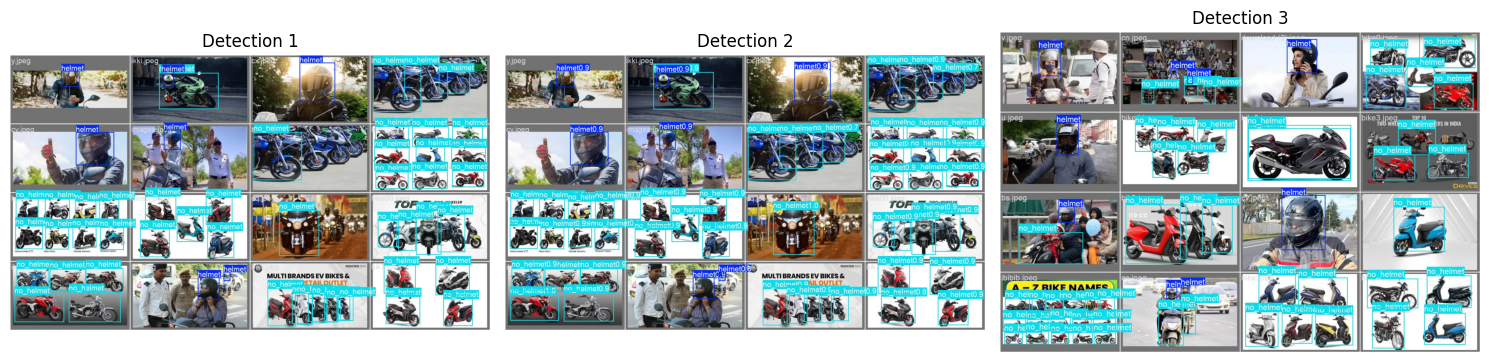

In [98]:
import matplotlib.pyplot as plt
import cv2
from glob import glob

# robust search (YOLO sometimes uses predict, predict2, etc.)
pred_images = glob("runs/detect/**/*.jpg", recursive=True)

# take only first 3
pred_images = pred_images[:3]

if len(pred_images) == 0:
    print("❌ No prediction images found. Run model.predict first.")
else:
    plt.figure(figsize=(15,5))

    for i, img_path in enumerate(pred_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, 3, i+1)
        plt.imshow(img)
        plt.title(f"Detection {i+1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()